# Task description

Реалізувати:
- відтворити інтенсивності переходу між станами у вигляді нелінійних функцій:
    - використовувати EM-алгоритм з ініціалізацією результатами кластеризації k середніх
- короткочасний прогноз з використанням ланцюгів Маркова
- обчислити ймовірності переходу в кожен зі станів залежно від величини горизонту прогнозування

#  Init

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from time_series import TimeSeries

In [50]:
class StateDiscretizer:
    def __init__(self, n_states: int = 3, random_state: int = 42):
        self.n_states = n_states
        self.random_state = random_state
        self.kmeans = None

    def fit(self, series: np.ndarray) -> np.ndarray:
        if not isinstance(series, np.ndarray):
            series = np.array(series)
        series_reshaped = series.reshape(-1, 1)
        self.kmeans = KMeans(
            n_clusters=self.n_states,
            random_state=self.random_state,
            n_init='auto'
        )
        self.kmeans.fit(series_reshaped)
        return self.kmeans.labels_

    @property
    def states(self) -> np.ndarray:
        if self.kmeans is None:
            raise RuntimeError("Model not fitted.")
        return self.kmeans.labels_

    @property
    def centers(self) -> np.ndarray:
        if self.kmeans is None:
            raise RuntimeError("Model not fitted.")
        return self.kmeans.cluster_centers_.flatten()

    def plot_discretization(self, series: np.ndarray):
        plt.figure(figsize=(12, 5))
        plt.plot(series, label="Original series")

        cmap = plt.get_cmap("tab10")
        for state in range(self.n_states):
            indices = np.where(self.states == state)[0]
            plt.scatter(
                indices,
                [self.centers[state]] * len(indices),
                color=cmap(state),
                label=f"State {state}",
                s=20
            )

        plt.title("Дискретизація часового ряду через кластеризацію k-середніх")
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [51]:
class MarkovModelEM:
    def __init__(self, n_states: int, n_iter: int = 100, tol: float = 1e-4):
        self.n_states = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.transition_matrix = None

    def _initialize_random(self):
        p = np.random.rand(self.n_states, self.n_states)
        return p / p.sum(axis=1, keepdims=True)

    def fit(self, state_sequence: np.ndarray):
        p = self._initialize_random()
        prev_ll = -np.inf

        for iteration in range(self.n_iter):
            transition_counts = np.zeros((self.n_states, self.n_states))

            for i in range(len(state_sequence) - 1):
                from_state = state_sequence[i]
                to_state = state_sequence[i + 1]
                transition_counts[from_state, to_state] += 1

            row_sums = transition_counts.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1
            p_new = transition_counts / row_sums

            log_likelihood = np.sum([
                np.log(p_new[state_sequence[i], state_sequence[i + 1]] + 1e-12)
                for i in range(len(state_sequence) - 1)
            ])

            if np.abs(log_likelihood - prev_ll) < self.tol:
                break

            p = p_new
            prev_ll = log_likelihood

        self.transition_matrix = p

    def get_forecast_path(self, current_state: int, horizon: int = 5) -> np.ndarray:
        if self.transition_matrix is None:
            raise RuntimeError("Model is not fitted.")

        probs = [np.eye(self.n_states)[current_state]]
        for _ in range(horizon):
            probs.append(probs[-1] @ self.transition_matrix)
        return np.array(probs)

    def predict_next_distribution(self, current_state: int, steps_ahead: int = 1) -> np.ndarray:
        return self.get_forecast_path(current_state, steps_ahead)[-1]

    def plot_forecast_distribution(self, current_state: int, horizon: int = 5):
        probs = self.get_forecast_path(current_state, horizon)
        plt.figure(figsize=(8, 5))
        for i in range(self.n_states):
            plt.plot(range(horizon + 1), probs[:, i], label=f"State {i}")
        plt.xlabel("Steps ahead")
        plt.ylabel("Probability")
        plt.title(f"Прогноз імовірностей станів на {horizon} кроків вперед\n(починаючи зі стану {current_state})")
        plt.legend()
        plt.grid(True)
        plt.show()

# Analyses

## Extract time series

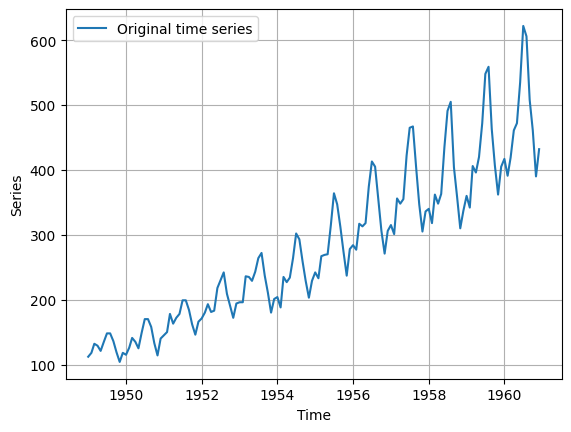

In [26]:
ts = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
ts.plot_series(label="Original time series")

## State Discretization

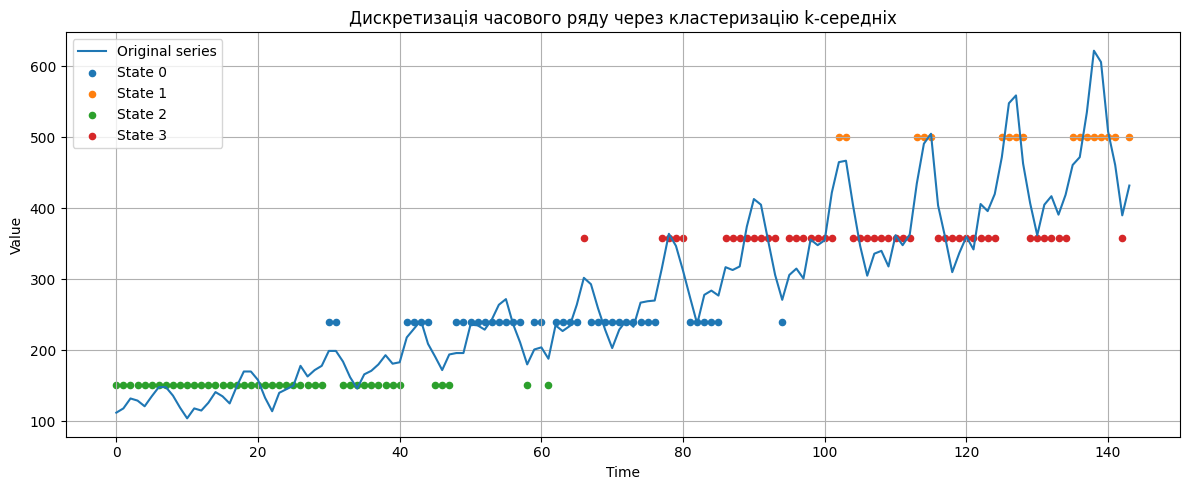

In [52]:
discretizer = StateDiscretizer(n_states=4)
discretizer.fit(ts.series)
discretizer.plot_discretization(ts.series)

## Markov Model

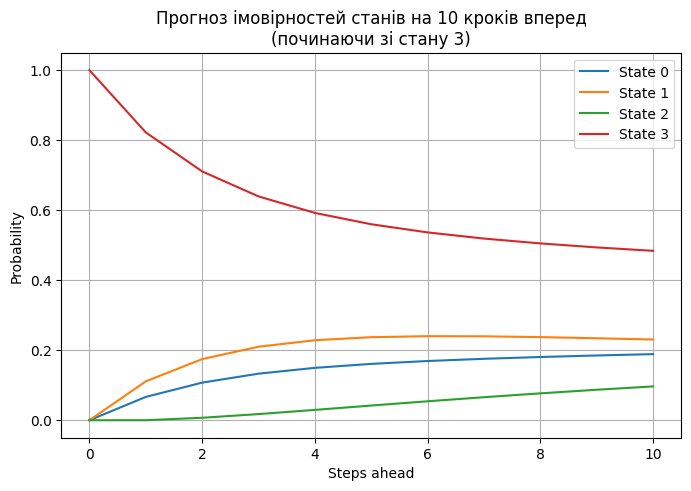

In [53]:
model = MarkovModelEM(n_states=4)
model.fit(discretizer.states)
model.plot_forecast_distribution(current_state=3, horizon=10)